In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.target.value_counts()

target
1    526
0    499
Name: count, dtype: int64

age            Axes(0.125,0.747241;0.227941x0.132759)
sex         Axes(0.398529,0.747241;0.227941x0.132759)
cp          Axes(0.672059,0.747241;0.227941x0.132759)
trestbps       Axes(0.125,0.587931;0.227941x0.132759)
chol        Axes(0.398529,0.587931;0.227941x0.132759)
fbs         Axes(0.672059,0.587931;0.227941x0.132759)
restecg        Axes(0.125,0.428621;0.227941x0.132759)
thalach     Axes(0.398529,0.428621;0.227941x0.132759)
exang       Axes(0.672059,0.428621;0.227941x0.132759)
oldpeak         Axes(0.125,0.26931;0.227941x0.132759)
slope        Axes(0.398529,0.26931;0.227941x0.132759)
ca           Axes(0.672059,0.26931;0.227941x0.132759)
thal               Axes(0.125,0.11;0.227941x0.132759)
target          Axes(0.398529,0.11;0.227941x0.132759)
dtype: object

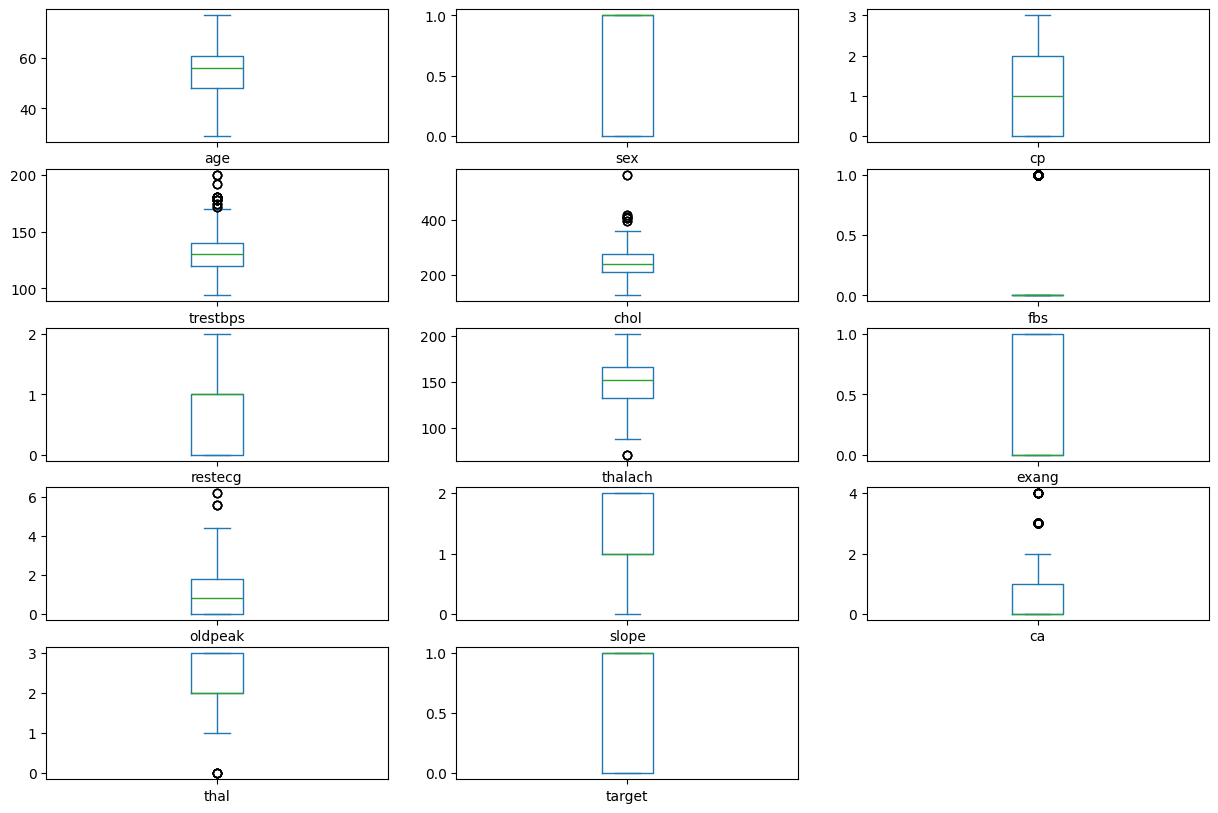

In [6]:
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,10))

age            Axes(0.125,0.747241;0.227941x0.132759)
sex         Axes(0.398529,0.747241;0.227941x0.132759)
cp          Axes(0.672059,0.747241;0.227941x0.132759)
trestbps       Axes(0.125,0.587931;0.227941x0.132759)
chol        Axes(0.398529,0.587931;0.227941x0.132759)
fbs         Axes(0.672059,0.587931;0.227941x0.132759)
restecg        Axes(0.125,0.428621;0.227941x0.132759)
thalach     Axes(0.398529,0.428621;0.227941x0.132759)
exang       Axes(0.672059,0.428621;0.227941x0.132759)
oldpeak         Axes(0.125,0.26931;0.227941x0.132759)
slope        Axes(0.398529,0.26931;0.227941x0.132759)
ca           Axes(0.672059,0.26931;0.227941x0.132759)
thal               Axes(0.125,0.11;0.227941x0.132759)
target          Axes(0.398529,0.11;0.227941x0.132759)
dtype: object

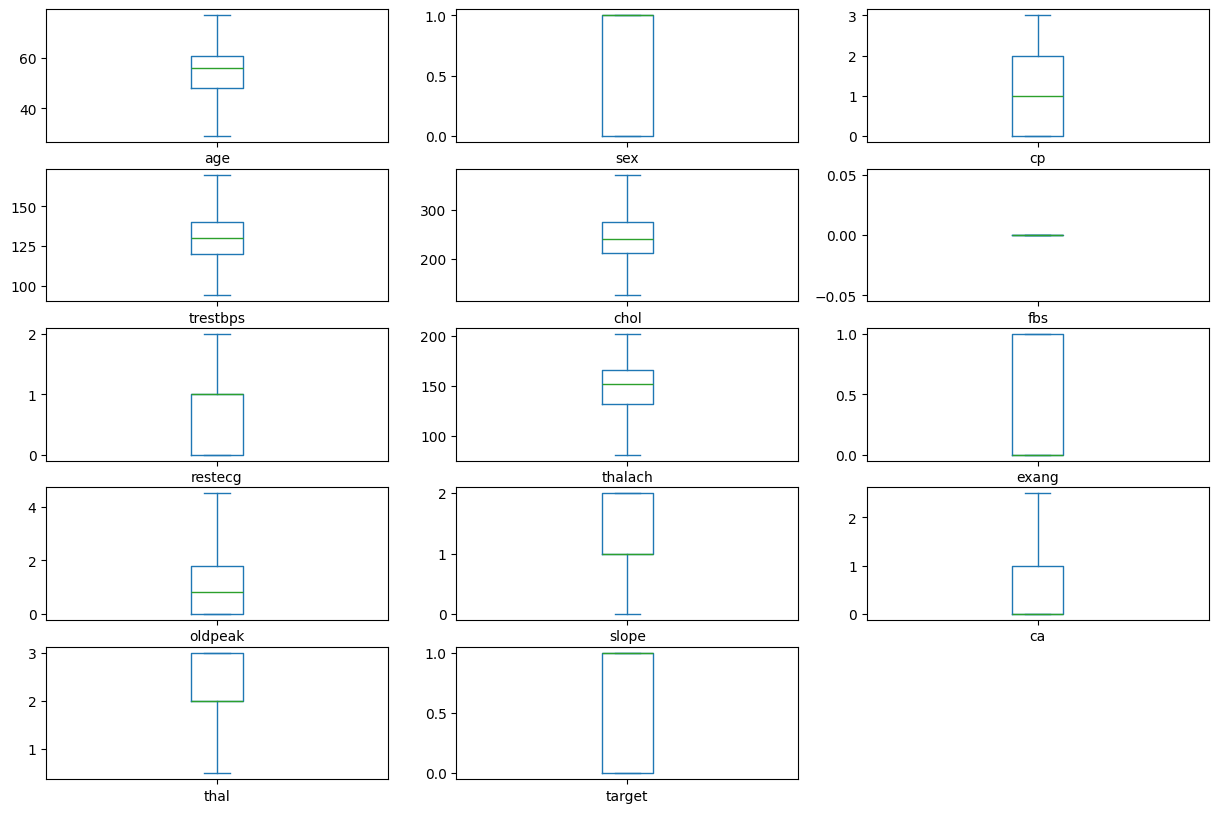

In [8]:
#iqr for trestbps,chol,fbs,thalach,oldpeak,slope,ca,thal
def out(col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    low=q1-1.5*iqr
    up=q3+1.5*iqr
    df[col]=df[col].clip(lower=low,upper=up)
out("trestbps")
out("chol")
out("fbs")
out("thalach")
out("oldpeak")
out("slope")
out("ca")
out("thal")
df.plot(kind="box",subplots=True,layout=(5,3),figsize=(15,10))

In [14]:
from sklearn.model_selection import train_test_split
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.75      0.72        96
           1       0.76      0.72      0.74       109

    accuracy                           0.73       205
   macro avg       0.73      0.73      0.73       205
weighted avg       0.73      0.73      0.73       205

[[72 24]
 [31 78]]


In [15]:
print("training score:",knn.score(x_train,y_train))
print("testing score:",knn.score(x_test,y_test))

training score: 0.9134146341463415
testing score: 0.7317073170731707


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop("Species",axis=1)
y=df["Species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3,metric="euclidean",p=2,weights="uniform")
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print("Training Accuracy:",knn.score(x_train,y_train))
print("Testing Accuracy:",knn.score(x_test,y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0
